In [ ]:
#Load packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
import xgboost as xgb

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import shap

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate

from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)

# Load Datasets

In [29]:
# Load the 1st dataset
df = pd.read_csv('Shopping_Behaviour_Dataset.csv')

# Overview of the data
print(df.shape) #shape of the data
print(df.columns.tolist()) #list of columns
print(df.head()) #sample entries
print(df.info()) #data types
print(df.isnull().sum()) #check for nulls

(3900, 18)
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Y

In [30]:
#Load the 2nd dataset
df2 = pd.read_csv('Ecommerce_Consumer_Behavior_Analysis_Data.csv')

#Overview of the data
print(df2.shape) #shape of the data
print(df2.columns.tolist()) #list of columns
print(df2.head()) #sample entries
print(df2.info()) #data types
print(df2.isnull().sum()) #check for nulls

(1000, 28)
['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence', 'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision']
   Customer_ID  Age  Gender Income_Level Marital_Status Education_Level  \
0  37-611-6911   22  Female       Middle        Married      Bachelor's   
1  29-392-9296   49    Male         High        Married     High School   
2  84-649-5117   24  Female       Middle         Single        Master's   
3  48-980-6078   29  Female       Middle         Single        Master's   
4  91-170-9072   33  Female       Middle        

# Compare Datasets

In [31]:
#Shipping Type was checked, but decided not to use because it is not the same as Shipping_Preference
df['Shipping Type'].unique()

array(['Express', 'Free Shipping', 'Next Day Air', 'Standard',
       '2-Day Shipping', 'Store Pickup'], dtype=object)

In [32]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [33]:
df2.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


# Merge 2 Datasets

In [34]:
#Fix dataset 1
df_fix = df[['Customer ID', 'Age', 'Gender', 'Category', 'Purchase Amount (USD)', 'Review Rating', 'Discount Applied', 'Subscription Status', 'Payment Method']]
df_fix = df_fix.rename(columns={"Customer ID": "cust_id", "Age": "age", "Gender": "gender", "Category": "category", "Purchase Amount (USD)": "purchase_amount", "Review Rating": "rating", "Discount Applied": "discount", "Subscription Status": "subscribed", "Payment Method": "payment_method"})
df_fix

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,1,55,Male,Clothing,53,3.1,Yes,Yes,Venmo
1,2,19,Male,Clothing,64,3.1,Yes,Yes,Cash
2,3,50,Male,Clothing,73,3.1,Yes,Yes,Credit Card
3,4,21,Male,Footwear,90,3.5,Yes,Yes,PayPal
4,5,45,Male,Clothing,49,2.7,Yes,Yes,PayPal
...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Clothing,28,4.2,No,No,Venmo
3896,3897,52,Female,Accessories,49,4.5,No,No,Bank Transfer
3897,3898,46,Female,Accessories,33,2.9,No,No,Venmo
3898,3899,44,Female,Footwear,77,3.8,No,No,Venmo


In [35]:
#Check payment method and ensure it matches with dataset 2
df_fix['payment_method'].unique()

array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)

In [36]:
# Source - https://stackoverflow.com/a/60946524
# Posted by tianlinhe, modified by community. See post 'Timeline' for change history
# Retrieved 2026-08-05, License - CC BY-SA 4.0

#Change values to match with dataset 2
df_fix['payment_method'] = df_fix['payment_method'].apply(lambda a: str(a).replace('Venmo','Other'))
df_fix['payment_method'] = df_fix['payment_method'].apply(lambda a: str(a).replace('Bank Transfer','Other'))

In [37]:
#Double check
df_fix['payment_method'].unique()

array(['Other', 'Cash', 'Credit Card', 'PayPal', 'Debit Card'],
      dtype=object)

In [38]:
#Check product category
df_fix['category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [39]:
#Change values to match with dataset 2
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Footwear','Clothing'))
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Outerwear','Clothing'))
df_fix['category'] = df_fix['category'].apply(lambda a: str(a).replace('Accessories','Jewelry & Accessories'))

In [40]:
#Convert data types
df_fix['purchase_amount'].astype(float)
df_fix['rating'].astype(float)

df_fix.head()

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,1,55,Male,Clothing,53,3.1,Yes,Yes,Other
1,2,19,Male,Clothing,64,3.1,Yes,Yes,Cash
2,3,50,Male,Clothing,73,3.1,Yes,Yes,Credit Card
3,4,21,Male,Clothing,90,3.5,Yes,Yes,PayPal
4,5,45,Male,Clothing,49,2.7,Yes,Yes,PayPal


In [41]:
#Check gender types
df_fix['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [42]:
#Fix dataset 2
df2_fix = df2[['Customer_ID', 'Age', 'Gender', 'Purchase_Category', 'Purchase_Amount', 'Customer_Satisfaction', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Payment_Method']]
df2_fix = df2_fix.rename(columns={"Customer_ID": "cust_id", "Age": "age", "Gender": "gender", "Purchase_Category": "category", "Purchase_Amount": "purchase_amount", "Customer_Satisfaction": "rating", "Discount_Used": "discount", "Customer_Loyalty_Program_Member": "subscribed", "Payment_Method": "payment_method"})
df2_fix

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,37-611-6911,22,Female,Gardening & Outdoors,$333.80,7,True,False,Credit Card
1,29-392-9296,49,Male,Food & Beverages,$222.22,5,True,False,PayPal
2,84-649-5117,24,Female,Office Supplies,$426.22,7,True,True,Debit Card
3,48-980-6078,29,Female,Home Appliances,$101.31,1,True,True,Other
4,91-170-9072,33,Female,Furniture,$211.70,10,False,False,Debit Card
...,...,...,...,...,...,...,...,...,...
995,20-562-2569,44,Female,Mobile Accessories,$463.67,4,True,False,PayPal
996,41-366-4205,50,Female,Gardening & Outdoors,$69.78,6,True,False,Cash
997,77-241-7621,26,Male,Food & Beverages,$453.37,6,True,True,Credit Card
998,53-091-2176,21,Female,Baby Products,$106.15,5,True,True,Cash


In [43]:
#Check payment method types
df2_fix['payment_method'].unique()

array(['Credit Card', 'PayPal', 'Debit Card', 'Other', 'Cash'],
      dtype=object)

In [44]:
#Check all types of categories
df2_fix['category'].unique()

array(['Gardening & Outdoors', 'Food & Beverages', 'Office Supplies',
       'Home Appliances', 'Furniture', 'Books', 'Sports & Outdoors',
       'Mobile Accessories', 'Luxury Goods', 'Animal Feed', 'Health Care',
       'Hotels', 'Packages)', 'Electronics', 'Software & Apps',
       'Baby Products', 'Toys & Games', 'Arts & Crafts',
       'Health Supplements', 'Groceries', 'Clothing',
       'Beauty & Personal Care', 'Travel & Leisure (Flights',
       'Jewelry & Accessories'], dtype=object)

In [45]:
#Change rating from over 10 to over 5
df2_fix['rating'] = df2_fix['rating'].astype(float)/2

In [46]:
#Clean purchase_amount to just the number by removing $ and , and changing to numeric type
df2_fix['purchase_amount'] = df2_fix['purchase_amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df2_fix['purchase_amount'] = pd.to_numeric(df2_fix['purchase_amount'], errors='coerce')

In [47]:
#Change 'True' to 'Yes' and 'False' to 'No'
df2_fix['discount'] = df2_fix['discount'].apply(lambda a: str(a).replace('True','Yes'))
df2_fix['discount'] = df2_fix['discount'].apply(lambda a: str(a).replace('False','No'))

df2_fix['subscribed'] = df2_fix['subscribed'].apply(lambda a: str(a).replace('True','Yes'))
df2_fix['subscribed'] = df2_fix['subscribed'].apply(lambda a: str(a).replace('False','No'))

In [48]:
#Remove - from customer ID then change to a number
df2_fix['cust_id'] = df2_fix['cust_id'].astype(str).str.replace('-', '', regex=False)
df2_fix['cust_id'] = pd.to_numeric(df2_fix['cust_id'], errors='coerce')

In [49]:
#Get all unique genders
df2_fix['gender'].unique()

array(['Female', 'Male', 'Bigender', 'Genderfluid', 'Non-binary',
       'Polygender', 'Agender', 'Genderqueer'], dtype=object)

In [50]:
#For simplicity, change other gender types to Queer
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Bigender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Genderfluid','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Non-binary','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Polygender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Agender','Queer'))
df2_fix['gender'] = df2_fix['gender'].apply(lambda a: str(a).replace('Genderqueer','Queer'))

In [51]:
df2_fix.head()

,cust_id,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
0,376116911,22,Female,Gardening & Outdoors,333.80,3.5,Yes,No,Credit Card
1,293929296,49,Male,Food & Beverages,222.22,2.5,Yes,No,PayPal
2,846495117,24,Female,Office Supplies,426.22,3.5,Yes,Yes,Debit Card
3,489806078,29,Female,Home Appliances,101.31,0.5,Yes,Yes,Other
4,911709072,33,Female,Furniture,211.70,5.0,No,No,Debit Card


In [52]:
#Merge 2 datasets
merged_df = pd.concat([df_fix, df2_fix], axis=0)

#Set customer ID as index so it will not be included as an input in the model
merged_df = merged_df.set_index('cust_id')
merged_df.head()

,age,gender,category,purchase_amount,rating,discount,subscribed,payment_method
cust_id,,,,,,,,
1,55,Male,Clothing,53.0,3.1,Yes,Yes,Other
2,19,Male,Clothing,64.0,3.1,Yes,Yes,Cash
3,50,Male,Clothing,73.0,3.1,Yes,Yes,Credit Card
4,21,Male,Clothing,90.0,3.5,Yes,Yes,PayPal
5,45,Male,Clothing,49.0,2.7,Yes,Yes,PayPal


In [53]:
merged_df.shape

(4900, 8)

In [27]:
merged_df.columns

Index(['age', 'gender', 'category', 'purchase_amount', 'rating', 'discount',
       'subscribed', 'payment_method'],
      dtype='object')

# ML Model 1: kMeans Clustering

In [60]:
# Convert Yes/No to 1/0
merged_df['discount'] = merged_df['discount'].map({'Yes': 1, 'No': 0})
merged_df['subscribed'] = merged_df['subscribed'].map({'Yes': 1, 'No': 0})

numeric_cols = ['age', 'purchase_amount', 'rating', 'discount', 'subscribed']
categorical_cols = ['gender', 'category', 'payment_method']

In [61]:
# preprocess numerical cols above using standard scaler, and categorical using one hot encoding
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),('cat', OneHotEncoder(drop='first'), categorical_cols)])
#fit and transform data after using preprocessor
X = preprocessor.fit_transform(merged_df)

#use elbow method and silhouette score to get optimal k clusters
inertia, sil = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=33, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

#list values in a table
k_scores = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertia,
    'silhouette': sil})

#print values
print(k_scores)

   k       inertia  silhouette
0  2  25076.867406    0.228806
1  3  20132.622846    0.260602
2  4  18028.954640    0.205468
3  5  16321.673611    0.209350
4  6  15417.958629    0.194953
5  7  14282.837154    0.202301
6  8  13745.454818    0.205128
7  9  13259.488072    0.175684


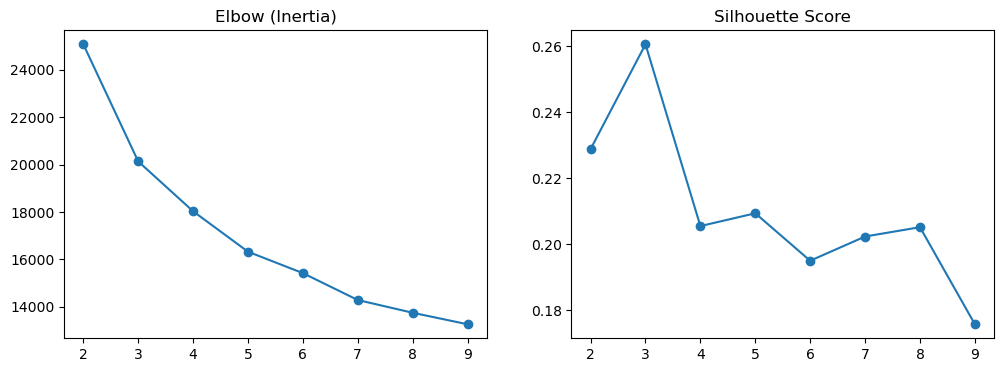

In [62]:
#plot inertia and silhouette scores to visualise best k
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertia, marker='o'); ax[0].set_title('Elbow (Inertia)')
ax[1].plot(k_range, sil, marker='o'); ax[1].set_title('Silhouette Score')
#plt.savefig('elbow_sil_graphs.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Test whether the selected k=3 solution is stable
# across different random initialisations

seeds = [1, 10, 20, 33, 42, 100]

results = []

for seed in seeds:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    results.append({'random_state': seed, 'silhouette_score': score})

seed_results = pd.DataFrame(results)

#print results
print(seed_results)
print("\nMean silhouette score:",
      seed_results['silhouette_score'].mean())
print("Standard deviation:",
      seed_results['silhouette_score'].std())
print("Minimum silhouette score:",
      seed_results['silhouette_score'].min())
print("Maximum silhouette score:",
      seed_results['silhouette_score'].max())

   random_state  silhouette_score
0             1          0.260602
1            10          0.260602
2            20          0.260602
3            33          0.260602
4            42          0.260602
5           100          0.260602

Mean silhouette score: 0.2606023330009651
Standard deviation: 6.080941944488117e-17
Minimum silhouette score: 0.26060233300096514
Maximum silhouette score: 0.26060233300096514


In [64]:
#fit kmeans model with k=3
kmeans = KMeans(n_clusters=3, random_state=33, n_init=10)
merged_df['cluster'] = kmeans.fit_predict(X)

In [ ]:
# Proportions of the dataset to test
sample_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

# Repeat each sample size using different random samples
sample_seeds = [1, 10, 20, 33, 42]

results = []

for size in sample_sizes:
    for seed in sample_seeds:
        # Use the full dataset when size = 1.0
        if size == 1.0:
            sample_df = merged_df.copy()
        else:
            sample_df = merged_df.sample(frac=size, random_state=seed)

        # Fit preprocessing separately on each sampled dataset
        sample_preprocessor = clone(preprocessor)
        X_sample = sample_preprocessor.fit_transform(sample_df)
        # Fit the same k=3 K-Means model
        km = KMeans(n_clusters=3, random_state=33, n_init=10)
        labels = km.fit_predict(X_sample)
        # Calculate clustering quality
        score = silhouette_score(X_sample, labels)

        results.append({
            'sample_size': size,
            'n_observations': len(sample_df),
            'seed': seed,
            'silhouette_score': score
        })

sample_results = pd.DataFrame(results)

# Summarise results by training set size
sample_summary = (
    sample_results
    .groupby(['sample_size', 'n_observations'])['silhouette_score']
    .agg(['mean', 'std'])
    .reset_index()
)

#print results
print(sample_summary)

   sample_size  n_observations      mean       std
0          0.2             980  0.261489  0.004575
1          0.4            1960  0.258352  0.003921
2          0.6            2940  0.258683  0.002223
3          0.8            3920  0.259956  0.001508
4          1.0            4900  0.260602  0.000000


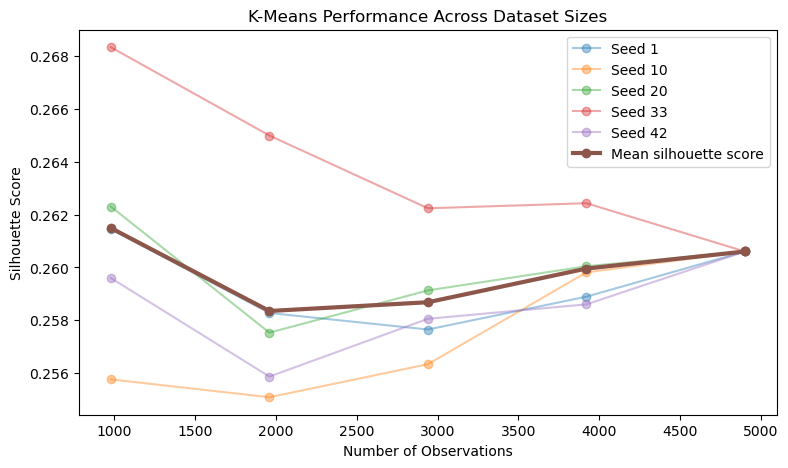

In [ ]:
plt.figure(figsize=(9, 5))

# plot individual runs
for seed in sample_seeds:
    seed_data = sample_results[sample_results['seed'] == seed]
    plt.plot(
        seed_data['n_observations'],
        seed_data['silhouette_score'],
        marker='o',
        alpha=0.4,
        label=f'Seed {seed}'
    )

# plot mean line more clearly
plt.plot(
    sample_summary['n_observations'],
    sample_summary['mean'],
    marker='o',
    linewidth=3,
    label='Mean silhouette score')

#show pplot
plt.xlabel('Number of Observations')
plt.ylabel('Silhouette Score')
plt.title('K-Means Performance Across Dataset Sizes')
plt.legend()
plt.show()

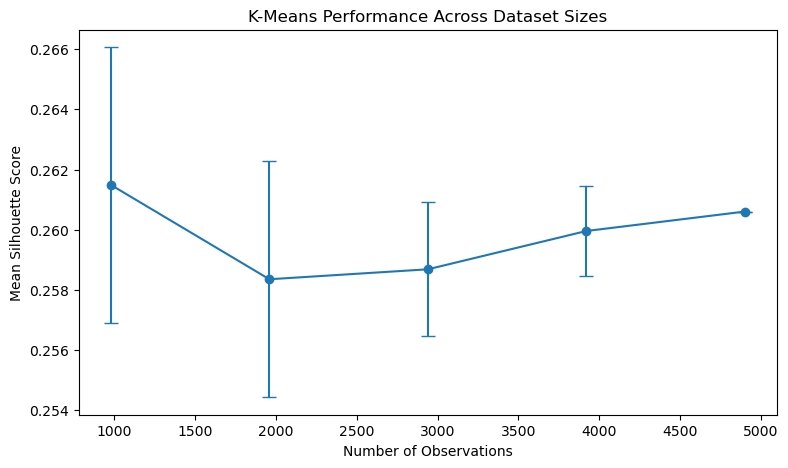

In [ ]:
#plot the mean silhouette score depending on number of observations
plt.figure(figsize=(9, 5))

plt.errorbar(
    sample_summary['n_observations'],
    sample_summary['mean'],
    yerr=sample_summary['std'],
    marker='o',
    capsize=5
)

plt.xlabel('Number of Observations')
plt.ylabel('Mean Silhouette Score')
plt.title('K-Means Performance Across Dataset Sizes')
plt.show()

# ML Model 2: XGBoost

In [70]:
#identify the target column and the other predictive features
target = 'subscribed'
features = ['age', 'gender', 'category', 'purchase_amount', 'rating',
            'discount', 'payment_method']

#create X for input features and Y for output or target
X = merged_df[features].copy()
y = merged_df[target]

#we convert back categoricals to category data type, since XGBoost can use these
for col in ['gender', 'category', 'payment_method']:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33, stratify=y) #we stratify to preserve the same proportions

In [ ]:
# Check whether stratified sampling preserved class proportions
print("Full dataset:")
print(y.value_counts(normalize=True).sort_index() * 100)

print("\nTraining set:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTest set:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Full dataset:
subscribed
0    68.489796
1    31.510204
Name: proportion, dtype: float64

Training set:
subscribed
0    68.494898
1    31.505102
Name: proportion, dtype: float64

Test set:
subscribed
0    68.469388
1    31.530612
Name: proportion, dtype: float64


In [72]:
#grad for gridsearch, to get optimal parameters
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

base_model = xgb.XGBClassifier(
    enable_categorical=True,
    eval_metric='logloss', #measures how good predicted probabilities are
    random_state=33
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='average_precision',  #takes into consideration the minority due to class imbalance
    cv=5,
    n_jobs=-1,
    verbose=2
)

#fit
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END 

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=1.0,
    enable_categorical=True,
    eval_metric='logloss',
    random_state=33
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
results = model.evals_result()

In [ ]:


# Use stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=33
)

# Metrics to evaluate
scoring = {
    'accuracy': 'accuracy',
    'subscriber_recall': 'recall',
    'subscriber_f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

# Evaluate the final XGBoost model across the 5 folds
cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# Show each fold
cv_table = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results['test_accuracy'],
    'Subscriber Recall': cv_results['test_subscriber_recall'],
    'Subscriber F1': cv_results['test_subscriber_f1'],
    'ROC-AUC': cv_results['test_roc_auc'],
    'Average Precision': cv_results['test_average_precision']
})

print(cv_table)

# Show mean and standard deviation
print("\nMean scores:")
print(cv_table.drop(columns='Fold').mean())

print("\nStandard deviations:")
print(cv_table.drop(columns='Fold').std())

   Fold  Accuracy  Subscriber Recall  Subscriber F1   ROC-AUC  \
0     1  0.756122           0.550162       0.587219  0.862554   
1     2  0.771429           0.546926       0.601423  0.858256   
2     3  0.762245           0.508091       0.574040  0.869366   
3     4  0.738776           0.556634       0.573333  0.833186   
4     5  0.753061           0.545455       0.581315  0.843081   

   Average Precision  
0           0.673137  
1           0.620133  
2           0.668892  
3           0.577696  
4           0.601471  

Mean scores:
Accuracy             0.756327
Subscriber Recall    0.541453
Subscriber F1        0.583466
ROC-AUC              0.853289
Average Precision    0.628266
dtype: float64

Standard deviations:
Accuracy             0.012061
Subscriber Recall    0.019140
Subscriber F1        0.011540
ROC-AUC              0.014810
Average Precision    0.041849
dtype: float64


In [ ]:
# Use stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=33)

# Test progressively larger amounts of the training data
train_sizes = [0.10, 0.25, 0.50, 0.75, 1.00]

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring='f1',          # F1 for subscriber class (1)
    shuffle=True,
    random_state=33,
    n_jobs=-1
)

# Calculate average performance and variation across folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Put results into a table
learning_summary = pd.DataFrame({
    'Training Size': train_sizes_abs,
    'Train F1 Mean': train_mean,
    'Train F1 SD': train_std,
    'Validation F1 Mean': val_mean,
    'Validation F1 SD': val_std
})

print(learning_summary)

   Training Size  Train F1 Mean  Train F1 SD  Validation F1 Mean  \
0            313       0.699290     0.039791            0.414940   
1            784       0.727940     0.063063            0.496399   
2           1568       0.719828     0.022539            0.532282   
3           2352       0.719038     0.005897            0.581528   
4           3136       0.693684     0.016869            0.564454   

   Validation F1 SD  
0          0.055092  
1          0.061951  
2          0.046109  
3          0.034687  
4          0.013362  


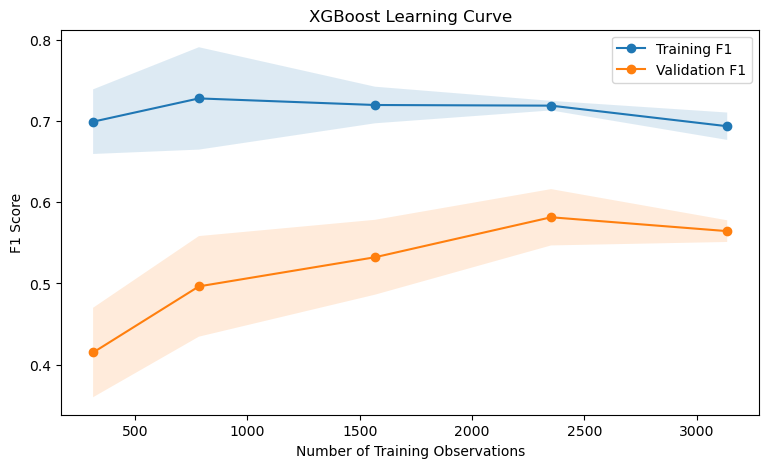

In [ ]:
#Graph for XGBoost to show F1 score across number of training observations
plt.figure(figsize=(9, 5))

# Training performance
plt.plot(
    train_sizes_abs,
    train_mean,
    marker='o',
    label='Training F1'
)

# Validation performance
plt.plot(
    train_sizes_abs,
    val_mean,
    marker='o',
    label='Validation F1'
)

# Show variability across folds
plt.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes_abs,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.xlabel('Number of Training Observations')
plt.ylabel('F1 Score')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()

In [126]:
#print classification report and AUC
print(classification_report(y_test, preds))
print("AUC:", round(roc_auc_score(y_test, probs), 3))

#output for latex
#report_dict = classification_report(y_test, preds, output_dict=True)
#report_df = pd.DataFrame(report_dict).transpose().round(3)
#print(report_df.to_latex())

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       671
           1       0.61      0.49      0.54       309

    accuracy                           0.74       980
   macro avg       0.70      0.67      0.68       980
weighted avg       0.73      0.74      0.73       980

AUC: 0.845
\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
0 & 0.783000 & 0.855000 & 0.818000 & 671.000000 \\
1 & 0.607000 & 0.485000 & 0.540000 & 309.000000 \\
accuracy & 0.739000 & 0.739000 & 0.739000 & 0.739000 \\
macro avg & 0.695000 & 0.670000 & 0.679000 & 980.000000 \\
weighted avg & 0.728000 & 0.739000 & 0.730000 & 980.000000 \\
\bottomrule
\end{tabular}



In [22]:
# Overall dataset size
print("Dataset shape:", merged_df.shape)

# Subscription distribution
print("\nSubscription counts:")
print(merged_df['subscribed'].value_counts())

print("\nSubscription proportions:")
print(merged_df['subscribed'].value_counts(normalize=True))

# Gender distribution
print("\nGender counts:")
print(merged_df['gender'].value_counts())

print("\nGender proportions:")
print(merged_df['gender'].value_counts(normalize=True))

Dataset shape: (4900, 8)

Subscription counts:
subscribed
No     3356
Yes    1544
Name: count, dtype: int64

Subscription proportions:
subscribed
No     0.684898
Yes    0.315102
Name: proportion, dtype: float64

Gender counts:
gender
Male      3101
Female    1700
Queer       99
Name: count, dtype: int64

Gender proportions:
gender
Male      0.632857
Female    0.346939
Queer     0.020204
Name: proportion, dtype: float64


In [24]:
# Add source labels temporarily for comparison
source_df = pd.concat([
    df_fix.assign(source='Dataset 1'),
    df2_fix.assign(source='Dataset 2')
], ignore_index=True)

# Subscription distribution by source dataset
print("Subscription counts by dataset:")
print(pd.crosstab(source_df['source'], source_df['subscribed']))

print("\nSubscription percentages by dataset:")
print(
    pd.crosstab(
        source_df['source'],
        source_df['subscribed'],
        normalize='index'
    ) * 100
)

# Gender distribution by source dataset
print("\nGender counts by dataset:")
print(pd.crosstab(source_df['source'], source_df['gender']))

print("\nGender percentages by dataset:")
print(
    pd.crosstab(
        source_df['source'],
        source_df['gender'],
        normalize='index'
    ) * 100
)

Subscription counts by dataset:
subscribed    No   Yes
source                
Dataset 1   2847  1053
Dataset 2    509   491

Subscription percentages by dataset:
subscribed    No   Yes
source                
Dataset 1   73.0  27.0
Dataset 2   50.9  49.1

Gender counts by dataset:
gender     Female  Male  Queer
source                        
Dataset 1    1248  2652      0
Dataset 2     452   449     99

Gender percentages by dataset:
gender     Female  Male  Queer
source                        
Dataset 1    32.0  68.0    0.0
Dataset 2    45.2  44.9    9.9


In [25]:
print("Overall subscription rate by gender:")
print(
    pd.crosstab(
        source_df['gender'],
        source_df['subscribed'],
        normalize='index'
    ) * 100
)

Overall subscription rate by gender:
subscribed         No        Yes
gender                          
Female      86.941176  13.058824
Male        58.626250  41.373750
Queer       60.606061  39.393939


In [26]:
print("\nSubscription rate by gender AND dataset:")
print(
    pd.crosstab(
        [source_df['source'], source_df['gender']],
        source_df['subscribed'],
        normalize='index'
    ) * 100
)


Subscription rate by gender AND dataset:
subscribed                No        Yes
source    gender                       
Dataset 1 Female  100.000000   0.000000
          Male     60.294118  39.705882
Dataset 2 Female   50.884956  49.115044
          Male     48.775056  51.224944
          Queer    60.606061  39.393939


In [ ]:
pd.crosstab(df_fix['gender'], df_fix['subscribed'])

subscribed,No,Yes
gender,,
Female,1248,0
Male,1599,1053


In [ ]:
pd.crosstab(df_fix['gender'], df_fix['subscribed'], normalize='index') * 100

subscribed,No,Yes
gender,,
Female,100.000000,0.000000
Male,60.294118,39.705882


In [ ]:
pd.crosstab(df['Gender'], df['Subscription Status'])

Subscription Status,No,Yes
Gender,,
Female,1248,0
Male,1599,1053


In [44]:
pip install fairlearn

Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install fairlearn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Generate predictions using the existing XGBoost test set
y_pred = model.predict(X_test)

# Retrieve gender for the same customers in the test set
gender_test = merged_df.loc[y_test.index, 'gender']

# Metrics to compare across gender groups
fairness_metrics = {
    'Accuracy': accuracy_score,
    'Precision': lambda y_true, y_pred: precision_score(
        y_true, y_pred, zero_division=0
    ),
    'Recall': lambda y_true, y_pred: recall_score(
        y_true, y_pred, zero_division=0
    ),
    'F1': lambda y_true, y_pred: f1_score(
        y_true, y_pred, zero_division=0
    ),
    'Selection Rate': selection_rate
}

metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)

print("Overall model performance:")
print(metric_frame.overall)

print("\nPerformance by gender:")
print(metric_frame.by_group)

print("\nNumber of customers by gender in test set:")
print(gender_test.value_counts())

Overall model performance:
Accuracy          0.738776
Precision         0.607287
Recall            0.485437
F1                0.539568
Selection Rate    0.252041
dtype: float64

Performance by gender:
        Accuracy  Precision    Recall        F1  Selection Rate
gender                                                         
Female  0.865497   0.625000  0.104167  0.178571        0.023392
Male    0.671521   0.607595  0.566929  0.586558        0.383495
Queer   0.650000   0.500000  0.142857  0.222222        0.100000

Number of customers by gender in test set:
gender
Male      618
Female    342
Queer      20
Name: count, dtype: int64


In [ ]:
#demographic parity diff
dp_difference = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)
#demographic parity ratio
dp_ratio = demographic_parity_ratio(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)
#equalised odds diff
eo_difference = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)

print("Demographic Parity Difference:", dp_difference)
print("Demographic Parity Ratio:", dp_ratio)
print("Equalized Odds Difference:", eo_difference)

Demographic Parity Difference: 0.3601033327655709
Demographic Parity Ratio: 0.06099637278851136
Equalized Odds Difference: 0.462762467191601
